  0%|          | 0/5 [00:00<?, ?it/s]

Working on mofc 


  0%|          | 0/27 [00:00<?, ?it/s]

Working on lofc 


  0%|          | 0/27 [00:00<?, ?it/s]

...

Working on dlPFC 


  0%|          | 0/27 [00:00<?, ?it/s]

Working on FFA-PPA 


  0%|          | 0/27 [00:00<?, ?it/s]

lofc-aa_rdm : 	 t= 4.41,p= 0.0002 mu=0.0125
lofc-bb_rdm : 	 t= 3.22,p= 0.0034 mu=0.0076
lofc-cc_rdm : 	 t= -0.92,p= 0.3661 mu=-0.0015
lofc-dd_rdm : 	 t= 3.44,p= 0.0020 mu=0.0067
mofc-aa_rdm : 	 t= 4.50,p= 0.0001 mu=0.0116
mofc-bb_rdm : 	 t= 1.19,p= 0.2443 mu=0.0024
mofc-cc_rdm : 	 t= -0.16,p= 0.8771 mu=-0.0004
mofc-dd_rdm : 	 t= 1.21,p= 0.2368 mu=0.0028
hp-aa_rdm : 	 t= 4.77,p= 0.0001 mu=0.0083
hp-bb_rdm : 	 t= 1.30,p= 0.2041 mu=0.0020
hp-cc_rdm : 	 t= 0.90,p= 0.3779 mu=0.0016
hp-dd_rdm : 	 t= -0.22,p= 0.8301 mu=-0.0003
dlPFC-aa_rdm : 	 t= 6.14,p= 0.0000 mu=0.0270
dlPFC-bb_rdm : 	 t= 3.41,p= 0.0021 mu=0.0101
dlPFC-cc_rdm : 	 t= -0.90,p= 0.3778 mu=-0.0023
dlPFC-dd_rdm : 	 t= 3.26,p= 0.0031 mu=0.0105
FFA-PPA-aa_rdm : 	 t= 3.29,p= 0.0029 mu=0.0100
FFA-PPA-bb_rdm : 	 t= 0.77,p= 0.4458 mu=0.0011
FFA-PPA-cc_rdm : 	 t= -1.53,p= 0.1391 mu=-0.0031
FFA-PPA-dd_rdm : 	 t= 0.85,p= 0.4038 mu=0.0021


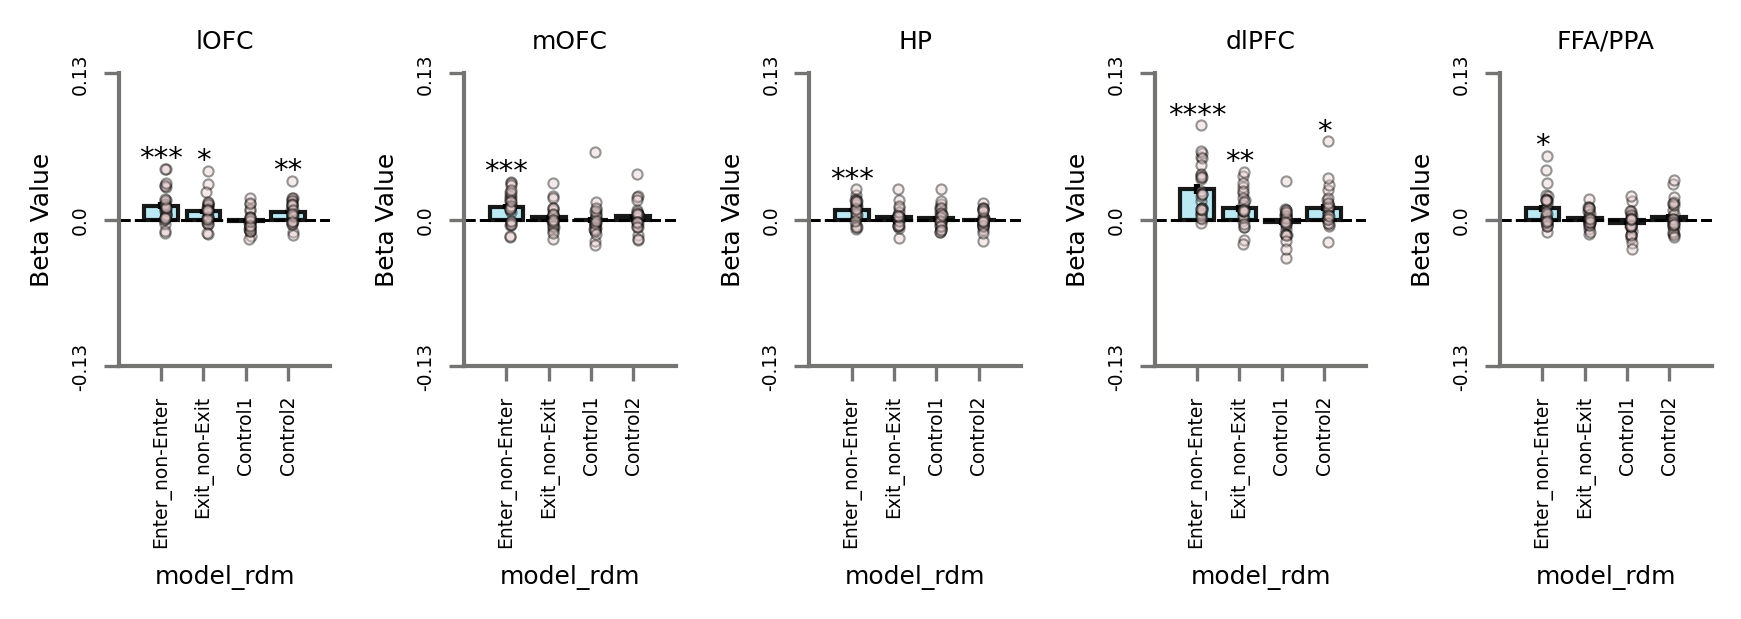

In [3]:
#tri_angle
from tqdm import tqdm_notebook
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import nibabel as nb
import statsmodels.api as sm
from scipy import stats
GREY_LIGHT = "#b4aea9"
GREY_DARK = "#747473"
from sklearn.preprocessing import LabelEncoder
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
mask_names = ['mofc','lofc','hp','dlPFC','FFA-PPA']

rdms = ['aa_rdm', 'bb_rdm', 'cc_rdm', 'dd_rdm']
titles = ['Enter_non-Enter', 'Exit_non-Exit', 'Control1', 'Control2']
theory_rdms = [np.load(f'/home/garlicseed/Mount/final/RSA/rdm_matrix/{rdm}.npy') for rdm in rdms]

subject_inds = [1,2,3,4,5,7,8,9,10,11,12,14,15,16,17,18,20,21,22,23,24,25,26,27,28,29,30]
index = pd.MultiIndex.from_product([subject_inds, mask_names], names=['subject', 'mask_name'])
df_scores = pd.DataFrame(index=index, columns=['aa_rdm', 'bb_rdm','cc_rdm','dd_rdm'])
for mask_name in tqdm_notebook(mask_names):
    print("Working on %s " %(mask_name))
    for i, current_subject in enumerate(tqdm_notebook(subject_inds)): 
        scaler = StandardScaler()
        neuro_rdm = np.load(f'/home/garlicseed/Mount/final/RSA/rdm_matrix/{mask_name}/sub-{current_subject:02}_{mask_name}_matrices_diagonal.npy')
        neuro_rdv = squareform(neuro_rdm.round(5))
        aa_rdm = np.load(f'/home/garlicseed/Mount/final/RSA/rdm_matrix/aa_rdm.npy')
        aa_rdv = squareform(aa_rdm)
        bb_rdm = np.load(f'/home/garlicseed/Mount/final/RSA/rdm_matrix/bb_rdm.npy')
        bb_rdv = squareform(bb_rdm)
        cc_rdm = np.load(f'/home/garlicseed/Mount/final/RSA/rdm_matrix/cc_rdm.npy')
        cc_rdv = squareform(cc_rdm)
        dd_rdm = np.load(f'/home/garlicseed/Mount/final/RSA/rdm_matrix/dd_rdm.npy')
        dd_rdv = squareform(dd_rdm)
        
        X = np.column_stack([aa_rdv, bb_rdv, cc_rdv, dd_rdv])
        X = sm.add_constant(X)  # 添加常数项
        # 进行多元线性回归
        model = sm.OLS(neuro_rdv, X).fit()        
        df_scores.loc[(current_subject, mask_name)] = model.params[1:]
        df_scores.reset_index()
        
df_scores.to_csv('/media/garlicseed/data/final/RSA/multiple_regression/Sorces/beta_values.tsv',sep='\t')
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_1samp

def plot_rdm_results(df_scores):
    #mask_names = df_scores.index.get_level_values('mask_name').unique()
    mask_names = ['lofc','mofc','hp','dlPFC','FFA-PPA']
    modelrdms = df_scores.columns
    COLOR_SCALE = ["#1B9E77", "#D95F02","#7570B3"]
    # setting figure size
    mm = 1 / 25.4
    f, axs = plt.subplots(1, len(mask_names), figsize=(150 * mm, 55 * mm), dpi=300)
    
    # Ensure axs is an array even when its length is 1
    if len(mask_names) == 1:
        axs = np.array([axs])

    for j, mask_name in enumerate(mask_names):  # for each mask_name
        for k, modelrdm in enumerate(modelrdms):
            avg_res = df_scores.loc[(slice(None), mask_name), modelrdm].values.astype(float)        

            t, p = ttest_1samp(avg_res, 0)
            print(f'{mask_name}-{modelrdm} : \t t= {t:.2f},p= {p:.4f} mu={avg_res.mean():.4f}')
            with open('/media/garlicseed/data/final/RSA/multiple_regression/Sorces/stats.txt', 'a') as f:
                f.write(f'{mask_name}-{modelrdm} : \t t= {t:.2f},p= {p:.4f} mu={avg_res.mean():.4f}\n')
            
            ts = ''
            if t > 0 and p < 0.05:
                if p < (0.0001 / 4):
                    ts = '*' * 4
                elif p < (0.001 / 4):
                    ts = '*' * 3
                elif p < (0.01 / 4):
                    ts = '*' * 2
                elif p < (0.05 / 4):
                    ts = '*'
                    
            axs[j].bar(k, avg_res.mean(), yerr=np.std(avg_res) / np.sqrt(len(avg_res)), 
                       color=(0.7, 0.9, 0.95), edgecolor='k',alpha=0.9)
            
            # modify scatter plot to adjust size, color
            
            axs[j].scatter(np.repeat(k,len(avg_res)) + 0.1 + np.random.randn(len(avg_res))*0.01,
                           avg_res, color=(.9, .8, .8), alpha=0.4, zorder=3, s=6, edgecolors='k', linewidth=0.5)
            axs[j].plot([-1,4],[0,0],'k--',linewidth=0.7)
            axs[j].set_xlabel('model_rdm', fontsize=6)
            axs[j].set_ylabel('Beta Value', fontsize=6)
            # use the mask_name as the title of each subplot
            if mask_name == 'FFA-PPA':
                axs[j].set_title('FFA/PPA', fontsize=6)
            elif mask_name == 'mofc':
                axs[j].set_title('mOFC', fontsize=6)
            elif mask_name == 'lofc':
                axs[j].set_title('lOFC', fontsize=6)
            elif mask_name == 'hp':
                axs[j].set_title('HP', fontsize=6)
            else:
                axs[j].set_title(mask_name, fontsize=6)


            
            #axs[j].set_ylim(round(df_scores.min().min(), 2), round(df_scores.max().max(), 2))  # set y-limits according to dataset
            #yticks = axs[j].get_yticks()
            #yticks = [round(ytick, 2) for ytick in yticks]
            #axs[j].set_yticklabels(yticks, fontsize=6)
            axs[j].set_xticks(np.arange(len(modelrdms)))
            axs[j].set_xlim(-1,4.0)
            axs[j].set_yticklabels(np.arange(-0.13,0.14,0.13),fontsize=4.5)
            axs[j].set_yticks(np.arange(-0.13,0.14,0.13))
            axs[j].set_xticklabels(list(titles), rotation=90, fontsize=4.5)
            axs[j].spines['top'].set_visible(False)
            axs[j].spines['right'].set_visible(False)
            axs[j].spines["left"].set_color(GREY_DARK)
            axs[j].spines["left"].set_linewidth(1)
            axs[j].spines["bottom"].set_color(GREY_DARK)
            axs[j].tick_params(axis='both', which='major',color = GREY_DARK)
            for label in axs[j].get_ymajorticklabels():
                label.set_rotation(90)
                #label.set_fontsize(10)
                label.set_verticalalignment('center')
            axs[j].spines["bottom"].set_linewidth(1)
            # add significance level text
            axs[j].text(k, np.max(avg_res)+0.002, ts, {'fontsize': 7, 'ha': 'center', 'fontweight': 'normal'})
            
    plt.tight_layout()
    plt.savefig("/media/garlicseed/data/final/RSA/multiple_regression/Figures/beta_value.svg", dpi=300, format="svg", bbox_inches='tight')
    plt.savefig("/media/garlicseed/data/final/RSA/multiple_regression/Figures/beta_value.png", dpi=300, format="png", bbox_inches='tight')
    plt.show()

# Call the function with your DataFrame
plot_rdm_results(df_scores)        

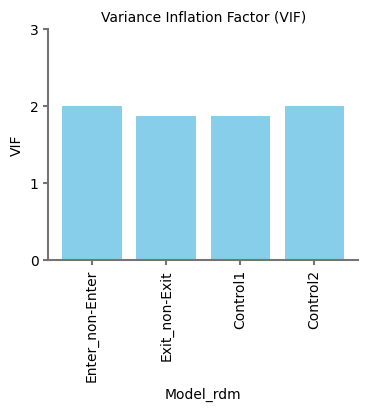

In [8]:
import pandas as pd
from scipy.spatial.distance import squareform
aa_rdm = np.load(f'/home/garlicseed/Mount/final/RSA/rdm_matrix/aa_rdm.npy')
aa_rdv = squareform(aa_rdm)
bb_rdm = np.load(f'/home/garlicseed/Mount/final/RSA/rdm_matrix/bb_rdm.npy')
bb_rdv = squareform(bb_rdm)
cc_rdm = np.load(f'/home/garlicseed/Mount/final/RSA/rdm_matrix/cc_rdm.npy')
cc_rdv = squareform(cc_rdm)
dd_rdm = np.load(f'/home/garlicseed/Mount/final/RSA/rdm_matrix/dd_rdm.npy')
dd_rdv = squareform(dd_rdm)
from statsmodels.stats.outliers_influence import variance_inflation_factor
df = pd.DataFrame({'aa_rdm':aa_rdv,'bb_rdm':bb_rdv,'cc_rdm':cc_rdv,'dd_rdm':dd_rdv})
vif = pd.DataFrame()
vif['variables'] = df.columns
vif['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
import matplotlib.pyplot as plt
GREY_LIGHT = "#b4aea9"
GREY_DARK = "#747473"
plt.figure(figsize=(4, 3))  # 创建一个新的图形
ax = plt.gca()  # 获取当前的axes
ax.spines['right'].set_color('none')  # 去掉右边的边框
ax.spines['top'].set_color('none')  # 去掉左边的边框
ax.spines["left"].set_color(GREY_DARK)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_DARK)
ax.spines["bottom"].set_linewidth(1.5)
ax.tick_params(axis='both', which='major',color = GREY_DARK,width=1.5)
ax.set_xticklabels(list(titles), rotation=90)
plt.bar(vif['variables'], vif['VIF'], color='skyblue')  # 创建一个条形图
plt.xlabel('Model_rdm')  
plt.ylabel('VIF')  
plt.ylim(0, 3)
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(['0','1', '2', '3'])
plt.title('Variance Inflation Factor (VIF)', fontsize=10)
plt.savefig("/media/garlicseed/data/final/RSA/multiple_regression/Figures/figure_vif.svg", dpi=300, format="svg", bbox_inches='tight')
plt.savefig("/media/garlicseed/data/final/RSA/multiple_regression/Figures/figure_vif.png", dpi=300, format="png", bbox_inches='tight')
plt.show()

,variables,VIF
0,aa,1.6
1,bb,1.8
2,ee,1.6


In [2]:
#tri_angle
from tqdm import tqdm_notebook
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import nibabel as nb
import statsmodels.api as sm
from scipy import stats
GREY_LIGHT = "#b4aea9"
GREY_DARK = "#747473"
from sklearn.preprocessing import LabelEncoder
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
mask_names = ['mofc','lofc','hp','dlPFC','FFA-PPA']

rdms = ['ee_rdm']
theory_rdms = [np.load(f'/home/garlicseed/Mount/final/RSA/rdm_matrix/{rdm}.npy') for rdm in rdms]

subject_inds = [1,2,3,4,5,7,8,9,10,11,12,14,15,16,17,18,20,21,22,23,24,25,26,27,28,29,30]
index = pd.MultiIndex.from_product([subject_inds, mask_names], names=['subject', 'mask_name'])
df_scores = pd.DataFrame(index=index, columns=['ee_rdm'])
for mask_name in tqdm_notebook(mask_names):
    print("Working on %s " %(mask_name))
    for i, current_subject in enumerate(tqdm_notebook(subject_inds)): 
        scaler = StandardScaler()
        neuro_rdm = np.load(f'/home/garlicseed/Mount/final/RSA/rdm_matrix/{mask_name}/sub-{current_subject:02}_{mask_name}_matrices_diagonal.npy')
        neuro_rdv = squareform(neuro_rdm.round(5))
        
        X = np.column_stack([squareform(rdm) for rdm in rdms])
        X = sm.add_constant(X)  # 添加常数项
        # 进行多元线性回归
        model = sm.OLS(neuro_rdv, X).fit()        
        df_scores.loc[(current_subject, mask_name)] = model.params[1:]
        df_scores.reset_index()
        
#df_scores.to_csv('/home/garlicseed/Mount/final/RSA/multiple_regression/Sorces/beta_values.tsv',sep='\t')
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_1samp

def plot_rdm_results(df_scores):
    #mask_names = df_scores.index.get_level_values('mask_name').unique()
    mask_names = ['lofc','mofc','hp','dlPFC','FFA-PPA']
    modelrdms = df_scores.columns
    COLOR_SCALE = ["#1B9E77", "#D95F02","#7570B3"]
    # setting figure size
    mm = 1 / 25.4
    f, axs = plt.subplots(1, len(mask_names), figsize=(150 * mm, 50 * mm), dpi=300)
    
    # Ensure axs is an array even when its length is 1
    if len(mask_names) == 1:
        axs = np.array([axs])

    for j, mask_name in enumerate(mask_names):  # for each mask_name
        for k, modelrdm in enumerate(modelrdms):
            avg_res = df_scores.loc[(slice(None), mask_name), modelrdm].values.astype(float)        

            t, p = ttest_1samp(avg_res, 0)
            print(f'{mask_name}-{modelrdm} : \t t= {t:.2f},p= {p:.4f} mu={avg_res.mean():.4f}')
            #with open('/home/garlicseed/Mount/final/RSA/multiple_regression/Sorces/stats.txt', 'a') as f:
                #f.write(f'{mask_name}-{modelrdm} : \t t= {t:.2f},p= {p:.4f} mu={avg_res.mean():.4f}\n')
            
            ts = ''
            if t > 0 and p < 0.05:
                if p < (0.0001 / 4):
                    ts = '*' * 4
                elif p < (0.001 / 4):
                    ts = '*' * 3
                elif p < (0.01 / 4):
                    ts = '*' * 2
                elif p < (0.05 / 4):
                    ts = '*'
                    
            axs[j].bar(k, avg_res.mean(), yerr=np.std(avg_res) / np.sqrt(len(avg_res)), 
                       color=(0.5, 0.7, 0.4), edgecolor='k',alpha=0.9)
            
            # modify scatter plot to adjust size, color
            
            axs[j].scatter(np.repeat(k,len(avg_res)) + 0.1 + np.random.randn(len(avg_res))*0.01,
                           avg_res, color=(.9, .8, .8), alpha=0.4, zorder=3, s=6, edgecolors='k', linewidth=0.5)
            axs[j].plot([-1,4],[0,0],'k--',linewidth=0.7)
            axs[j].set_xlabel('modelrdm', fontsize=6)
            axs[j].set_ylabel('Beta Value', fontsize=6)
            # use the mask_name as the title of each subplot
            if mask_name == 'FFA-PPA':
                axs[j].set_title('FFA/PPA', fontsize=6)
            elif mask_name == 'mofc':
                axs[j].set_title('mOFC', fontsize=6)
            elif mask_name == 'lofc':
                axs[j].set_title('lOFC', fontsize=6)
            elif mask_name == 'hp':
                axs[j].set_title('HP', fontsize=6)
            else:
                axs[j].set_title(mask_name, fontsize=6)


            
            #axs[j].set_ylim(round(df_scores.min().min(), 2), round(df_scores.max().max(), 2))  # set y-limits according to dataset
            #yticks = axs[j].get_yticks()
            #yticks = [round(ytick, 2) for ytick in yticks]
            #axs[j].set_yticklabels(yticks, fontsize=6)
            axs[j].set_xticks(np.arange(len(modelrdms)))
            axs[j].set_xlim(-1,4.0)
            axs[j].set_yticklabels(np.arange(-0.12,0.13,0.12),fontsize=6)
            axs[j].set_yticks(np.arange(-0.12,0.13,0.12))
            axs[j].set_xticklabels(list(modelrdms), rotation=90, fontsize=6)
            axs[j].spines['top'].set_visible(False)
            axs[j].spines['right'].set_visible(False)
            axs[j].spines["left"].set_color(GREY_DARK)
            axs[j].spines["left"].set_linewidth(1)
            axs[j].spines["bottom"].set_color(GREY_DARK)
            axs[j].tick_params(axis='both', which='major',color = GREY_DARK)
            for label in axs[j].get_ymajorticklabels():
                label.set_rotation(90)
                #label.set_fontsize(10)
                label.set_verticalalignment('center')
            axs[j].spines["bottom"].set_linewidth(1)
            # add significance level text
            axs[j].text(k, np.max(avg_res)+0.002, ts, {'fontsize': 7, 'ha': 'center', 'fontweight': 'normal'})
            
    plt.tight_layout()

    plt.show()

# Call the function with your DataFrame
plot_rdm_results(df_scores)  

  0%|          | 0/5 [00:00<?, ?it/s]

Working on mofc 


  0%|          | 0/27 [00:00<?, ?it/s]

UFuncTypeError: ufunc 'maximum' did not contain a loop with signature matching types (dtype('<U6'), dtype('<U6')) -> None

NameError: name 'df_scores' is not defined

In [4]:
avg_res

NameError: name 'avg_res' is not defined